In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import json
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [ ]:
data_file_path = '../data/censusbureau.data'
columns_file_path = '../data/census-bureau.columns'
with open(columns_file_path, 'r') as f:
    columns = [line.strip() for line in f if line.strip()]
df = pd.read_csv(data_file_path, header=None)
df.columns = columns

In [ ]:
df.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,?,?,?,Not in universe under 1 year old,?,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [ ]:
target = 'label'
weight_column = 'weight'
continuous_columns = ['age','wage per hour','capital gains','capital losses','dividends from stocks','num persons worked for employer','weeks worked in year']
categorical_columns = [col for col in df.columns if col not in continuous_columns + [target,weight_column]]
print(categorical_columns)

['class of worker', 'detailed industry recode', 'detailed occupation recode', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's admin", 'veterans benefits', 'year']


# Data Preprocessing

## Data Cleaning

In [ ]:
# Handling Target variable
df['label'] = df['label'].map({'- 50000.': 0, '50000+.': 1})

In [ ]:
# Merging Duplicates
cols = [c for c in df.columns if c != 'weight']
df = df.groupby(cols, as_index=False, dropna=False).agg(weight=('weight', 'sum'))
df.shape

(152896, 42)

In [ ]:
# Handling Missing values
print(df.isna().sum().to_json())
df.columns[df.eq('?').any()]

{"age":0,"class of worker":0,"detailed industry recode":0,"detailed occupation recode":0,"education":0,"wage per hour":0,"enroll in edu inst last wk":0,"marital stat":0,"major industry code":0,"major occupation code":0,"race":0,"hispanic origin":848,"sex":0,"member of a labor union":0,"reason for unemployment":0,"full or part time employment stat":0,"capital gains":0,"capital losses":0,"dividends from stocks":0,"tax filer stat":0,"region of previous residence":0,"state of previous residence":0,"detailed household and family stat":0,"detailed household summary in household":0,"migration code-change in msa":0,"migration code-change in reg":0,"migration code-move within reg":0,"live in this house 1 year ago":0,"migration prev res in sunbelt":0,"num persons worked for employer":0,"family members under 18":0,"country of birth father":0,"country of birth mother":0,"country of birth self":0,"citizenship":0,"own business or self employed":0,"fill inc questionnaire for veteran's admin":0,"veter

Index(['state of previous residence', 'migration code-change in msa',
       'migration code-change in reg', 'migration code-move within reg',
       'migration prev res in sunbelt', 'country of birth father',
       'country of birth mother', 'country of birth self'],
      dtype='object')

In [ ]:
# Handling NaN in 'Hispanic Origin' -> Replacing to 'Do not know' preexisting values
df['hispanic origin'].value_counts(dropna=False)
df['hispanic origin'] = df['hispanic origin'].fillna('Do not know')

In [ ]:
# '?' present only in categorical variable
print('Rows with ? values - ',df.apply(lambda row: row.astype(str).str.contains('?', regex=False).any(), axis=1).sum()) # count of rows with '?' - 104393

Rows with ? values -  79463


In [ ]:
# Replacing ? with 'Unknown' as an extra category
df[categorical_columns] = df[categorical_columns].replace('?', 'Unknown')

In [ ]:
#ORDINAL RANKING OF education based on levels / to reduce feature dimensionality
education_rank = {
    'Children': 1,
    'Less than 1st grade': 2,
    '1st 2nd 3rd or 4th grade': 3,
    '5th or 6th grade': 4,
    '7th and 8th grade': 5,
    '9th grade': 6,
    '10th grade': 7,
    '11th grade': 8,
    '12th grade no diploma': 9,
    'High school graduate': 10,
    'Some college but no degree': 11,
    'Associates degree-occup /vocational': 12,
    'Associates degree-academic program': 13,
    'Bachelors degree(BA AB BS)': 14,
    'Masters degree(MA MS MEng MEd MSW MBA)': 15,
    'Prof school degree (MD DDS DVM LLB JD)': 16,
    'Doctorate degree(PhD EdD)': 17
}
df['education'] = df['education'].map(education_rank)

In [ ]:
categorical_columns.remove('education')
continuous_columns.append('education')

In [ ]:
for col in categorical_columns:
    df[col] = df[col].astype('category')

In [ ]:
# TEST TRAIN SPLIT
from sklearn.model_selection import train_test_split

X = df.drop(columns=['label','weight'])
y = df['label']
w = df['weight']

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w,
    test_size=0.2,
    random_state=121,
    stratify=y
)
print(len(X_train),len(X_test))

122316 30580


In [ ]:
# #Checking Distribution (to ensure stratified sampling among features)


# for i in categorical_columns:
#   print(i)
#   print(X_train[i].value_counts(dropna=False,normalize = True))
#   print(X_test[i].value_counts(dropna=False,normalize = True))

# Modeling

Main Evaluation Metric: Weighted PR-AUC <br>
Reason: dataset is imbalanced, and want to find positives without flooding false alarms

## Logistic Regression

### Baseline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns),
    ('cont', StandardScaler(), continuous_columns)  # scaling directly here
])

log_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('lr_model', LogisticRegression(random_state = 131))
])

log_clf.fit(X_train, y_train, lr_model__sample_weight = w_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['class of worker',
                                                   'detailed industry recode',
                                                   'detailed occupation recode',
                                                   'enroll in edu inst last wk',
                                                   'marital stat',
                                                   'major industry code',
                                                   'major occupation code',
                                                   'race', 'hispanic origin',
                                                   'sex',
                                                   'member of a labor union',
                                                   'reason for unemploym...
                                                   'country of birth mother',
                                                   'country of birth self',
                                                   'citizenship',
                                                   'own business or self '
                                                   'employed',
                                                   'fill inc questionnaire for '
                                                   "veteran's admin", ...]),
                                                 ('cont', StandardScaler(),
                                                  ['age', 'wage per hour',
                                                   'capital gains',
                                                   'capital losses',
                                                   'dividends from stocks',
                                                   'num persons worked for '
                                                   'employer',
                                                   'weeks worked in year',
                                                   'education'])])),
                ('lr_model', LogisticRegression(random_state=131))])

In [ ]:
print("\n=== Logistic Regression (Weighted results)===\n")
from sklearn.linear_model import *
from sklearn.metrics import *

y_pred = log_clf.predict(X_test)
y_proba = log_clf.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, y_proba, sample_weight = w_test)
f1 = f1_score(y_test, y_pred, sample_weight = w_test)
roc = roc_auc_score(y_test, y_proba, sample_weight = w_test)
print(f"PR-AUC: {pr_auc:.4f}  |  F1: {f1:.4f}  |  ROC-AUC: {roc:.4f}")

print(classification_report(y_test, y_pred, sample_weight = w_test))

cf_matrix =  confusion_matrix(y_test, y_pred,  sample_weight = w_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred, sample_weight = w_test))



=== Logistic Regression (Weighted results)===

PR-AUC: 0.6124  |  F1: 0.5073  |  ROC-AUC: 0.9446
              precision    recall  f1-score   support

           0       0.96      0.99      0.97 64078555.48999995
           1       0.73      0.39      0.51 4482235.690000001

    accuracy                           0.95 68560791.17999995
   macro avg       0.84      0.69      0.74 68560791.17999995
weighted avg       0.94      0.95      0.94 68560791.17999995

Confusion Matrix:
 [[63430663.85999992   647891.63      ]
 [ 2738964.22        1743271.47      ]]


### PCA

In [ ]:
# with PCA
log_clf_pca = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95)),
    ('lr_model', LogisticRegression(random_state = 131))
])
log_clf_pca.fit(X_train, y_train, lr_model__sample_weight = w_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['class of worker',
                                                   'detailed industry recode',
                                                   'detailed occupation recode',
                                                   'enroll in edu inst last wk',
                                                   'marital stat',
                                                   'major industry code',
                                                   'major occupation code',
                                                   'race', 'hispanic origin',
                                                   'sex',
                                                   'member of a labor union',
                                                   'reason for unemploym...
                                                   'country of birth self',
                                                   'citizenship',
                                                   'own business or self '
                                                   'employed',
                                                   'fill inc questionnaire for '
                                                   "veteran's admin", ...]),
                                                 ('cont', StandardScaler(),
                                                  ['age', 'wage per hour',
                                                   'capital gains',
                                                   'capital losses',
                                                   'dividends from stocks',
                                                   'num persons worked for '
                                                   'employer',
                                                   'weeks worked in year',
                                                   'education'])])),
                ('pca', PCA(n_components=0.95)),
                ('lr_model', LogisticRegression(random_state=131))])

In [ ]:
print("\n=== Logistic Regression with PCA (Weighted results)===\n")
from sklearn.linear_model import *
from sklearn.metrics import *

y_pred = log_clf_pca.predict(X_test)
y_proba = log_clf_pca.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, y_proba, sample_weight = w_test)
f1 = f1_score(y_test, y_pred, sample_weight = w_test)
roc = roc_auc_score(y_test, y_proba, sample_weight = w_test)
print(f"PR-AUC: {pr_auc:.4f}  |  F1: {f1:.4f}  |  ROC-AUC: {roc:.4f}")

print(classification_report(y_test, y_pred, sample_weight = w_test))

cf_matrix =  confusion_matrix(y_test, y_pred,  sample_weight = w_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred, sample_weight = w_test))



=== Logistic Regression with PCA (Weighted results)===

PR-AUC: 0.6098  |  F1: 0.5039  |  ROC-AUC: 0.9440
              precision    recall  f1-score   support

           0       0.96      0.99      0.97 64078555.48999995
           1       0.74      0.38      0.50 4482235.690000001

    accuracy                           0.95 68560791.17999995
   macro avg       0.85      0.69      0.74 68560791.17999995
weighted avg       0.94      0.95      0.94 68560791.17999995

Confusion Matrix:
 [[63468673.2899999   609882.2      ]
 [ 2767289.23       1714946.46     ]]


### Weight of Evidence



In [ ]:
# Rules related to WOE
# Each category (bin) should have at least 5% of the observations.
# Each category (bin) should be non-zero for both non-events and events.
# The WOE should be distinct for each category. Similar groups should be aggregated.
# The WOE should be monotonic, i.e. either growing or decreasing with the groupings.
# Missing values are binned separately.

def calculate_woe_iv(data, target, bins=10):
    data = data.copy()
    woe_iv_mapping = {}
    bin_edges_mapping = {}
    iv_summary = []

    for col in data.columns:
        if col == target:
            continue

        if col in continuous_columns:  # Continuous columns
            unique_vals = data[col].nunique()
            num_bins = min(bins, unique_vals)  # Use fewer bins if unique values are less than specified bins
            try:
                data[col], bin_edges = pd.qcut(data[col], q=num_bins, retbins=True, duplicates='drop')
            except ValueError:
                data[col], bin_edges = pd.cut(data[col], bins=num_bins, retbins=True, duplicates='drop')
            bin_edges_mapping[col] = bin_edges

        else:  # Categorical columns
            data[col] = data[col].astype(str)

        # Calculate WoE and IV
        woe_df = data.groupby(col)[target].agg(['count', 'sum'])
        woe_df.columns = ['total', 'bad']
        woe_df['good'] = woe_df['total'] - woe_df['bad']
        woe_df['dist_good'] = woe_df['good'] / woe_df['good'].sum()
        woe_df['dist_bad'] = woe_df['bad'] / woe_df['bad'].sum()
        woe_df['woe'] = np.log(woe_df['dist_good'] / woe_df['dist_bad']).replace([np.inf, -np.inf], 0)
        woe_df['iv'] = (woe_df['dist_good'] - woe_df['dist_bad']) * woe_df['woe']
        iv = woe_df['iv'].sum()

        # Store WoE mapping
        woe_iv_mapping[col] = woe_df['woe'].to_dict()
        iv_summary.append({'feature': col, 'iv': iv})

    # Convert IV summary to DataFrame
    iv_summary = pd.DataFrame(iv_summary).sort_values(by='iv', ascending=False)
    return woe_iv_mapping, bin_edges_mapping, iv_summary


df_train_woe = pd.concat([X_train, y_train], axis=1)
woe_mapping, bin_edges_mapping, iv_summary = calculate_woe_iv(df_train_woe, target='label')

In [ ]:
iv_summary

,feature,iv
3,detailed occupation recode,1.845856
4,education,1.698894
0,age,1.496357
9,major occupation code,1.489658
19,tax filer stat,1.323142
22,detailed household and family stat,1.309297
23,detailed household summary in household,1.300901
38,weeks worked in year,1.048630
2,detailed industry recode,0.973204
8,major industry code,0.909938


In [ ]:
bin_edges_mapping

{'age': array([ 0., 16., 23., 28., 33., 38., 43., 49., 57., 68., 90.]),
 'education': array([ 1.,  3.,  7., 10., 11., 13., 14., 17.]),
 'wage per hour': array([   0., 9916.]),
 'capital gains': array([    0., 99999.]),
 'capital losses': array([   0., 4608.]),
 'dividends from stocks': array([    0.,   100., 99999.]),
 'num persons worked for employer': array([0., 1., 3., 4., 6.]),
 'weeks worked in year': array([ 0., 20., 45., 52.])}

In [ ]:
def apply_woe_mapping(data, woe_mapping, bin_edges_mapping):
    transformed_data = data.copy()

    for col, mapping in woe_mapping.items():
        if col not in transformed_data.columns:
            continue

        if col in continuous_columns:
            binned = pd.cut(
                transformed_data[col],
                bins=bin_edges_mapping[col],
                include_lowest=True
            )
            transformed_data[col] = binned.map(mapping)  # still Categorical here
            transformed_data[col] = transformed_data[col].astype(float).fillna(0)  # cast first, then fillna

        else:
            transformed_data[col] = (
                transformed_data[col]
                .astype(str)
                .map(mapping)
                .fillna(0)
                .astype(float)
            )

    return transformed_data

df_train_woe = apply_woe_mapping(df_train_woe, woe_mapping, bin_edges_mapping)
df_test_woe  = pd.concat([X_test, y_test], axis=1)
df_test_woe  = apply_woe_mapping(df_test_woe, woe_mapping, bin_edges_mapping)

In [ ]:
df_train_woe.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
121785,-0.778731,1.654370,1.659978,1.659978,2.246709,0.0,-0.076547,-0.469791,1.659978,1.659978,-0.096647,-0.130914,0.925552,0.073664,-0.029032,0.155758,0.0,0.0,0.320635,-0.599874,-0.059949,-0.059949,0.296070,0.296536,-0.032173,-0.032173,-0.032173,-0.032173,-0.025926,0.830965,-0.137538,-0.104165,-0.101722,-0.054075,-0.054054,0.047254,0.006753,-0.090064,1.958308,0.090507,0
127865,-0.172777,1.654370,1.659978,1.659978,0.797105,0.0,-0.076547,-0.469791,1.659978,1.659978,0.825014,-0.130914,0.925552,0.073664,-0.029032,0.155758,0.0,0.0,0.320635,4.510787,-0.059949,-0.059949,0.296070,0.296536,-0.032173,-0.032173,-0.032173,-0.032173,-0.025926,0.830965,-0.137538,-0.104165,-0.101722,-0.054075,-0.054054,0.047254,0.006753,-0.090064,1.958308,0.090507,0
121733,-0.778731,1.654370,1.659978,1.659978,0.797105,0.0,-0.076547,0.785194,1.659978,1.659978,-0.096647,-0.130914,0.925552,0.073664,-0.029032,0.155758,0.0,0.0,0.320635,4.510787,-0.059949,-0.059949,-0.071483,-0.568395,-0.032173,-0.032173,-0.032173,-0.032173,-0.025926,0.830965,-0.137538,-0.104165,-0.101722,-0.054075,-0.054054,0.047254,0.006753,-0.090064,1.958308,0.090507,0
108517,-0.778731,-1.090801,-0.402451,0.212291,2.246709,0.0,-0.076547,-0.469791,-0.402451,1.012017,0.014108,-0.130914,-0.537252,0.073664,-0.029032,-0.555816,0.0,0.0,0.320635,-0.599874,-0.059949,-0.059949,-0.725988,-0.568395,-0.087701,-0.087701,-0.087701,-0.082476,-0.087701,-0.667600,-0.137538,-0.075120,0.009921,-0.091804,-0.238299,0.047254,0.006753,-0.090064,-0.653741,-0.087701,0
72702,-0.357756,1.654370,1.659978,1.659978,-1.974185,0.0,-0.076547,-0.469791,1.659978,1.659978,-0.096647,-0.130914,0.925552,0.073664,-0.029032,0.155758,0.0,0.0,0.320635,-0.599874,-0.059949,-0.059949,0.296070,0.296536,-0.032173,-0.032173,-0.032173,-0.032173,-0.025926,0.830965,-0.137538,-0.075120,0.009921,-0.054075,-0.054054,0.047254,0.006753,-0.090064,1.958308,0.090507,0


In [ ]:
woe_imp_features = iv_summary[iv_summary["iv"]>0.02].feature.to_list()
print(woe_imp_features)

['detailed occupation recode', 'education', 'age', 'major occupation code', 'tax filer stat', 'detailed household and family stat', 'detailed household summary in household', 'weeks worked in year', 'detailed industry recode', 'major industry code', 'class of worker', 'family members under 18', 'marital stat', 'sex', 'dividends from stocks', 'num persons worked for employer', 'enroll in edu inst last wk', 'full or part time employment stat', 'hispanic origin', 'country of birth father', 'country of birth mother', 'country of birth self', 'race', 'state of previous residence', 'citizenship', 'migration code-change in msa', 'reason for unemployment', 'migration code-move within reg', 'migration code-change in reg', 'region of previous residence', 'migration prev res in sunbelt', 'live in this house 1 year ago', 'own business or self employed', 'member of a labor union']


In [ ]:
X_train_woe, X_test_woe, y_train_woe, y_test_woe = df_train_woe.drop(["label"],axis=1), df_test_woe.drop(["label"],axis=1), df_train_woe["label"], df_test_woe["label"]

In [ ]:
# with WOE
selector = ColumnTransformer([
    ('select', 'passthrough', woe_imp_features)  # just select, no transform needed since already WOE
], remainder='drop')

log_clf_woe = Pipeline([
    ('selector', selector),
    ('lr_model', LogisticRegression(random_state = 131))
])
log_clf_woe.fit(X_train_woe, y_train_woe, lr_model__sample_weight = w_train)

Pipeline(steps=[('selector',
                 ColumnTransformer(transformers=[('select', 'passthrough',
                                                  ['detailed occupation recode',
                                                   'education', 'age',
                                                   'major occupation code',
                                                   'tax filer stat',
                                                   'detailed household and '
                                                   'family stat',
                                                   'detailed household summary '
                                                   'in household',
                                                   'weeks worked in year',
                                                   'detailed industry recode',
                                                   'major industry code',
                                                   'class of worker',
                                                   'family members under 18',
                                                   'mar...
                                                   'employment stat',
                                                   'hispanic origin',
                                                   'country of birth father',
                                                   'country of birth mother',
                                                   'country of birth self',
                                                   'race',
                                                   'state of previous '
                                                   'residence',
                                                   'citizenship',
                                                   'migration code-change in '
                                                   'msa',
                                                   'reason for unemployment',
                                                   'migration code-move within '
                                                   'reg',
                                                   'migration code-change in '
                                                   'reg',
                                                   'region of previous '
                                                   'residence', ...])])),
                ('lr_model', LogisticRegression(random_state=131))])

In [ ]:
print("\n=== Logistic Regression with PCA (Weighted results)===\n")
from sklearn.linear_model import *
from sklearn.metrics import *

y_pred = log_clf_woe.predict(X_test_woe)
y_proba = log_clf_woe.predict_proba(X_test_woe)[:, 1]
pr_auc = average_precision_score(y_test_woe, y_proba, sample_weight = w_test)
f1 = f1_score(y_test_woe, y_pred, sample_weight = w_test)
roc = roc_auc_score(y_test_woe, y_proba, sample_weight = w_test)
print(f"PR-AUC: {pr_auc:.4f}  |  F1: {f1:.4f}  |  ROC-AUC: {roc:.4f}")

print(classification_report(y_test_woe, y_pred, sample_weight = w_test))

cf_matrix =  confusion_matrix(y_test_woe, y_pred,  sample_weight = w_test)
print("Confusion Matrix:\n", confusion_matrix(y_test_woe, y_pred, sample_weight = w_test))



=== Logistic Regression with PCA (Weighted results)===

PR-AUC: 0.5631  |  F1: 0.4484  |  ROC-AUC: 0.9352
              precision    recall  f1-score   support

           0       0.96      0.99      0.97 64078555.48999995
           1       0.68      0.33      0.45 4482235.690000001

    accuracy                           0.95 68560791.17999995
   macro avg       0.82      0.66      0.71 68560791.17999995
weighted avg       0.94      0.95      0.94 68560791.17999995

Confusion Matrix:
 [[63375194.05999995   703361.43      ]
 [ 2983512.33        1498723.36      ]]


Summary

1. Logistic baseline - (0.6124 PR-AUC) <br>
2. Logistic with PCA - (0.6098 PR-AUC) <br>
3. Logistic with WOE - (0.5631 PR-AUC) <br>

Winner - Logistic baseline


Now Coefficient check

### Coefficient analysis

In [ ]:
cat_feature_names = log_clf.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_columns).tolist()
all_feature_names = cat_feature_names + continuous_columns
coef = log_clf.named_steps['lr_model'].coef_[0]

coef_df = pd.DataFrame({'feature': all_feature_names,'coefficient': coef,'abs_coefficient': np.abs(coef)}).sort_values('abs_coefficient', ascending=False)

In [ ]:
coef_df.head(20)

,feature,coefficient,abs_coefficient
35,detailed industry recode_26,1.473855,1.473855
195,tax filer stat_Nonfiler,-1.366819,1.366819
15,detailed industry recode_6,-1.109168,1.109168
493,education,1.065123,1.065123
68,detailed occupation recode_7,1.027736,1.027736
461,country of birth self_Scotland,1.019364,1.019364
106,detailed occupation recode_45,0.977516,0.977516
92,detailed occupation recode_31,-0.975786,0.975786
222,state of previous residence_Maine,0.974611,0.974611
22,detailed industry recode_13,0.970300,0.970300


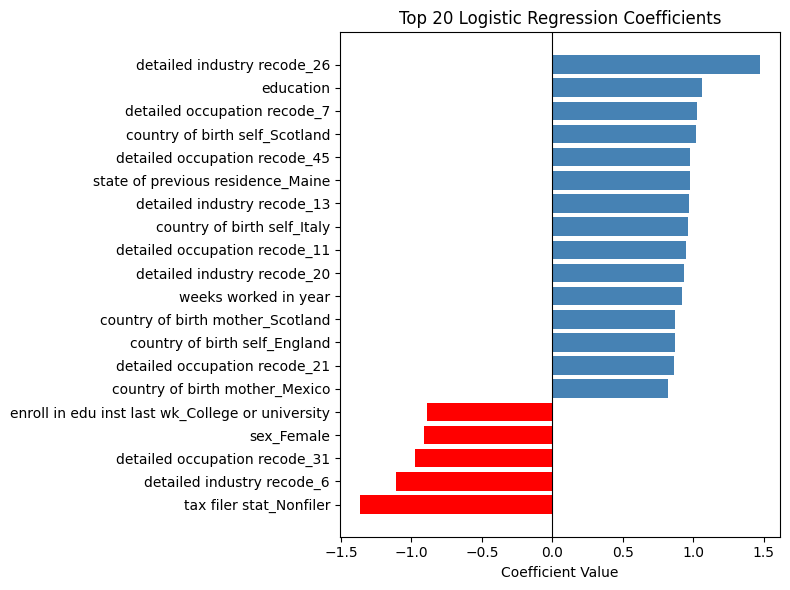

In [ ]:
top_n = 20

plot_df = coef_df.head(top_n).sort_values('coefficient')

plt.figure(figsize=(8, 6))
colors = ['red' if c < 0 else 'steelblue' for c in plot_df['coefficient']]
plt.barh(plot_df['feature'], plot_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Top {top_n} Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

Summary

Positive predictors:

* detailed industry recode_26 (coef 1.47) <br>
* education (coef 1.07) :  more education -> higher income, expected <br>
* detailed occupation recode_7, 45, 11, 21 : certain occupation codes push probability up<br>
* weeks worked in year (coef 0.92) : more weeks worked -> higher income <br>
* Geographic/birth features : small sample, likely noise <br>

Negative predictors:

* tax filer stat_Nonfiler (coef -1.37) : people who don't file taxes are  associated with lower income <br>
* detailed industry recode_6, 31: certain occupation pushes probability down <br>
* sex_Female (coef -0.91) : women are predicted lower income, reflects real-world wage gap <br>
* enroll in edu inst last wk_College (coef -0.89) : students currently enrolled likely have lower current income<br>

High cardinality and sparsity is introducing extreme coeffs


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
preprocessor_rf = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns),
    ('cont', 'passthrough', continuous_columns)  # no scaling for trees
])
rf_clf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('rf_model', RandomForestClassifier(random_state=131, class_weight='balanced'))
])
rf_clf.fit(X_train, y_train, rf_model__sample_weight=w_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['class of worker',
                                                   'detailed industry recode',
                                                   'detailed occupation recode',
                                                   'enroll in edu inst last wk',
                                                   'marital stat',
                                                   'major industry code',
                                                   'major occupation code',
                                                   'race', 'hispanic origin',
                                                   'sex',
                                                   'member of a labor union',
                                                   'reason for unemploym...
                                                   'country of birth self',
                                                   'citizenship',
                                                   'own business or self '
                                                   'employed',
                                                   'fill inc questionnaire for '
                                                   "veteran's admin", ...]),
                                                 ('cont', 'passthrough',
                                                  ['age', 'wage per hour',
                                                   'capital gains',
                                                   'capital losses',
                                                   'dividends from stocks',
                                                   'num persons worked for '
                                                   'employer',
                                                   'weeks worked in year',
                                                   'education'])])),
                ('rf_model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=131))])

In [ ]:
selected_columns = ['age', 'education', 'dividends from stocks', 'capital gains', 'detailed occupation recode', 'detailed industry recode', 'num persons worked for employer', 'weeks worked in year', 'major industry code', 'sex', 'major occupation code', 'capital losses', 'class of worker', 'tax filer stat', 'marital stat', 'detailed household and family stat', 'country of birth father', 'country of birth mother', 'own business or self employed', 'member of a labor union', 'detailed household summary in household', 'full or part time employment stat', 'wage per hour', 'race', 'country of birth self']

In [ ]:
print("\n=== Random Forest (Weighted results)===\n")
from sklearn.linear_model import *
from sklearn.metrics import *

y_pred = rf_clf.predict(X_test)
y_proba = rf_clf.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, y_proba, sample_weight = w_test)
f1 = f1_score(y_test, y_pred, sample_weight = w_test)
roc = roc_auc_score(y_test, y_proba, sample_weight = w_test)
print(f"PR-AUC: {pr_auc:.4f}  |  F1: {f1:.4f}  |  ROC-AUC: {roc:.4f}")
print("\nWeighted Classification Report \n")
print(classification_report(y_test, y_pred, sample_weight = w_test))

cf_matrix =  confusion_matrix(y_test, y_pred,  sample_weight = w_test)
print(" \n Weighted Confusion Matrix:\n\n", confusion_matrix(y_test, y_pred, sample_weight = w_test))



=== Random Forest (Weighted results)===

PR-AUC: 0.6074  |  F1: 0.4968  |  ROC-AUC: 0.9384

Weighted Classification Report 

              precision    recall  f1-score   support

           0       0.96      0.99      0.97 64078555.48999995
           1       0.72      0.38      0.50 4482235.690000001

    accuracy                           0.95 68560791.17999995
   macro avg       0.84      0.68      0.74 68560791.17999995
weighted avg       0.94      0.95      0.94 68560791.17999995

 
 Weighted Confusion Matrix:

 [[63411177.93999995   667377.55      ]
 [ 2780124.07        1702111.62      ]]


## CatBoost

In [ ]:
from catboost import CatBoostClassifier
cat_col_indices = [X_train.columns.get_loc(col) for col in categorical_columns]
cb_clf = CatBoostClassifier(
    random_state=131,
    eval_metric='PRAUC',
    verbose=100
)
cb_clf.fit(X_train, y_train, cat_features=cat_col_indices,sample_weight = w_train)

Learning rate set to 0.080221
0:	learn: 0.5318621	total: 285ms	remaining: 4m 45s
100:	learn: 0.5747300	total: 1m 8s	remaining: 10m 6s
200:	learn: 0.6437120	total: 2m 27s	remaining: 9m 45s
300:	learn: 0.6938619	total: 4m 18s	remaining: 10m 1s
400:	learn: 0.7100381	total: 6m 10s	remaining: 9m 13s
500:	learn: 0.7224282	total: 8m 1s	remaining: 7m 59s
600:	learn: 0.7322801	total: 9m 55s	remaining: 6m 35s
700:	learn: 0.7406936	total: 11m 48s	remaining: 5m 2s
800:	learn: 0.7470142	total: 13m 39s	remaining: 3m 23s
900:	learn: 0.7528565	total: 15m 29s	remaining: 1m 42s
999:	learn: 0.7579183	total: 17m 20s	remaining: 0us


CatBoostClassifier(eval_metric='PRAUC', random_state=131, verbose=100)

In [ ]:
print("\n=== CatBOOST (Weighted results)===\n")

from sklearn.linear_model import *
from sklearn.metrics import *

y_pred = cb_clf.predict(X_test)
y_proba = cb_clf.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_proba, sample_weight = w_test)
f1 = f1_score(y_test, y_pred, sample_weight = w_test)
roc = roc_auc_score(y_test, y_proba, sample_weight = w_test)
print(f"PR-AUC: {pr_auc:.4f}  |  F1: {f1:.4f}  |  ROC-AUC: {roc:.4f}")
print("\nWeighted Classification Report \n")
print(classification_report(y_test, y_pred, sample_weight = w_test))

cf_matrix =  confusion_matrix(y_test, y_pred,  sample_weight = w_test)
print(" \n Weighted Confusion Matrix:\n\n", confusion_matrix(y_test, y_pred, sample_weight = w_test))



=== CatBOOST (Weighted results)===

PR-AUC: 0.7013  |  F1: 0.6011  |  ROC-AUC: 0.9559

Weighted Classification Report 

              precision    recall  f1-score   support

           0       0.97      0.99      0.98 64078555.48999995
           1       0.78      0.49      0.60 4482235.690000001

    accuracy                           0.96 68560791.17999995
   macro avg       0.87      0.74      0.79 68560791.17999995
weighted avg       0.95      0.96      0.95 68560791.17999995

 
 Weighted Confusion Matrix:

 [[63451725.57999995   626829.91      ]
 [ 2286948.53        2195287.16      ]]


## XGBoost

In [ ]:
from xgboost import XGBClassifier
scale = w_train[y_train== 0].sum() / w_train[y_train == 1].sum()
xgb_clf = XGBClassifier(random_state=131,scale_pos_weight= scale, enable_categorical = True,eval_metric='aucpr' )
xgb_clf.fit(X_train, y_train,sample_weight=w_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print("\n=== XGBOOST (Weighted results)===\n")

from sklearn.linear_model import *
from sklearn.metrics import *

y_pred = xgb_clf.predict(X_test)
y_proba = xgb_clf.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_proba, sample_weight = w_test)
f1 = f1_score(y_test, y_pred, sample_weight = w_test)
roc = roc_auc_score(y_test, y_proba, sample_weight = w_test)
print(f"PR-AUC: {pr_auc:.4f}  |  F1: {f1:.4f}  |  ROC-AUC: {roc:.4f}")
print("\nWeighted Classification Report \n")
print(classification_report(y_test, y_pred, sample_weight = w_test))

cf_matrix =  confusion_matrix(y_test, y_pred,  sample_weight = w_test)
print(" \n Weighted Confusion Matrix:\n\n", confusion_matrix(y_test, y_pred, sample_weight = w_test))



=== XGBOOST (Weighted results)===

PR-AUC: 0.6383  |  F1: 0.5109  |  ROC-AUC: 0.9366

Weighted Classification Report 

              precision    recall  f1-score   support

           0       0.99      0.91      0.94 64078555.48999995
           1       0.37      0.80      0.51 4482235.690000001

    accuracy                           0.90 68560791.17999995
   macro avg       0.68      0.86      0.73 68560791.17999995
weighted avg       0.95      0.90      0.92 68560791.17999995

 
 Weighted Confusion Matrix:

 [[58055516.70000011  6023038.79      ]
 [  878117.44        3604118.25      ]]


## Light GBM

In [ ]:
w_train[y_train== 0].sum() / w_train[y_train == 1].sum()

np.float64(14.69260382165141)

In [ ]:
import lightgbm as lgb
scale = w_train[y_train== 0].sum() / w_train[y_train == 1].sum()
cat_col_indices = [X_train.columns.get_loc(col) for col in categorical_columns]

lgbm_clf = lgb.LGBMClassifier(random_state=131,scale_pos_weight= scale, categorical_feature = cat_col_indices)
lgbm_clf.fit(X_train, y_train,sample_weight=w_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] categorical_feature is set=1,2,3,6,7,8,9,10,11,12,13,14,15,19,20,21,22,23,24,25,26,27,28,30,31,32,33,34,35,36,37,39, categorical_column=1,2,3,6,7,8,9,10,11,12,13,14,15,19,20,21,22,23,24,25,26,27,28,30,31,32,33,34,35,36,37,39 will be ignored. Current value: categorical_feature=1,2,3,6,7,8,9,10,11,12,13,14,15,19,20,21,22,23,24,25,26,27,28,30,31,32,33,34,35,36,37,39
[LightGBM] [Info] Number of positive: 9894, number of negative: 112422
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.108768 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1387
[LightGBM] [Info] Number of data points in the train set: 122316, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.063724 -> initscore=-2.687344
[LightGBM] [Info] Start trai

LGBMClassifier(categorical_feature=[1, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,
                                    19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30,
                                    31, 32, 33, 34, 35, 36, ...],
               random_state=131,
               scale_pos_weight=np.float64(14.69260382165141))

In [ ]:
print("\n=== Light GBM (Weighted results)===\n")

from sklearn.linear_model import *
from sklearn.metrics import *

y_pred = lgbm_clf.predict(X_test)
y_proba = lgbm_clf.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_proba, sample_weight = w_test)
f1 = f1_score(y_test, y_pred, sample_weight = w_test)
roc = roc_auc_score(y_test, y_proba, sample_weight = w_test)
print(f"PR-AUC: {pr_auc:.4f}  |  F1: {f1:.4f}  |  ROC-AUC: {roc:.4f}")
print("\nWeighted Classification Report \n")
print(classification_report(y_test, y_pred, sample_weight = w_test))

cf_matrix =  confusion_matrix(y_test, y_pred,  sample_weight = w_test)
print(" \n Weighted Confusion Matrix:\n\n", confusion_matrix(y_test, y_pred, sample_weight = w_test))



=== Light GBM (Weighted results)===

PR-AUC: 0.6824  |  F1: 0.4963  |  ROC-AUC: 0.9528

Weighted Classification Report 

              precision    recall  f1-score   support

           0       0.99      0.88      0.93 64078555.48999995
           1       0.35      0.88      0.50 4482235.690000001

    accuracy                           0.88 68560791.17999995
   macro avg       0.67      0.88      0.72 68560791.17999995
weighted avg       0.95      0.88      0.91 68560791.17999995

 
 Weighted Confusion Matrix:

 [[56585768.55000011  7492786.94      ]
 [  529416.27        3952819.42      ]]


Summary of Models Experimentation

1. Logistic baseline - (0.6124 PR-AUC)
2. Random Forest - (0.6074 PR-AUC)
3. Catboost - (0.7013 PR-AUC)
4. XGBoost - (0.6383 PR-AUC)
5. LightGBM - (0.6824 PR-AUC)


# Catboost - Winner

Further tuning Catboost model

### Experiment - Early stopping + Eval Set

In [ ]:
from catboost import CatBoostClassifier, Pool

train_pool = Pool(
    X_train, y_train,
    cat_features=cat_col_indices,
    weight=w_train
)

val_pool = Pool(
    X_test, y_test,
    cat_features=cat_col_indices,
    weight=w_test
)

cb_clf = CatBoostClassifier(
    random_state=131,
    eval_metric='PRAUC',
    iterations=3000,        # set high, early stopping will cut it
    early_stopping_rounds=100,  # stop if no improvement for 100 rounds
    verbose=100
)

cb_clf.fit(train_pool, eval_set=val_pool)

Learning rate set to 0.064412
0:	learn: 0.5318621	test: 0.5326880	best: 0.5326880 (0)	total: 173ms	remaining: 8m 38s
100:	learn: 0.5576041	test: 0.5518560	best: 0.5518560 (99)	total: 1m 14s	remaining: 35m 48s
200:	learn: 0.5883804	test: 0.5832293	best: 0.5832293 (200)	total: 3m 18s	remaining: 46m 9s
300:	learn: 0.6763354	test: 0.6688599	best: 0.6688599 (300)	total: 5m 18s	remaining: 47m 37s
400:	learn: 0.6969884	test: 0.6822287	best: 0.6822287 (400)	total: 7m 24s	remaining: 48m 1s
500:	learn: 0.7108872	test: 0.6890016	best: 0.6890361 (495)	total: 9m 29s	remaining: 47m 21s
600:	learn: 0.7206119	test: 0.6931123	best: 0.6931243 (598)	total: 11m 36s	remaining: 46m 20s
700:	learn: 0.7283793	test: 0.6959967	best: 0.6959967 (700)	total: 13m 42s	remaining: 44m 58s
800:	learn: 0.7355944	test: 0.6982220	best: 0.6982220 (800)	total: 15m 50s	remaining: 43m 29s
900:	learn: 0.7415400	test: 0.6995793	best: 0.6995793 (900)	total: 17m 57s	remaining: 41m 49s
1000:	learn: 0.7471472	test: 0.7009088	best: 

CatBoostClassifier(early_stopping_rounds=100, eval_metric='PRAUC', iterations=3000, random_state=131, verbose=100)

In [ ]:
from sklearn.metrics import average_precision_score

y_proba = cb_clf.predict_proba(X_test)[:, 1]
y_pred = cb_clf.predict(X_test)

pr_auc = average_precision_score(y_test, y_proba, sample_weight = w_test)
f1 = f1_score(y_test, y_pred, sample_weight = w_test)
roc = roc_auc_score(y_test, y_proba, sample_weight = w_test)
print("Weighted results")
print(f"PR-AUC: {pr_auc:.4f}  |  F1: {f1:.4f}  |  ROC-AUC: {roc:.4f}")

Weighted results
PR-AUC: 0.7041  |  F1: 0.5926  |  ROC-AUC: 0.9565


PR-AUC improved from 0.7013 to 0.7041

### Feature Selection based on feature importances - to reduce dimensionality

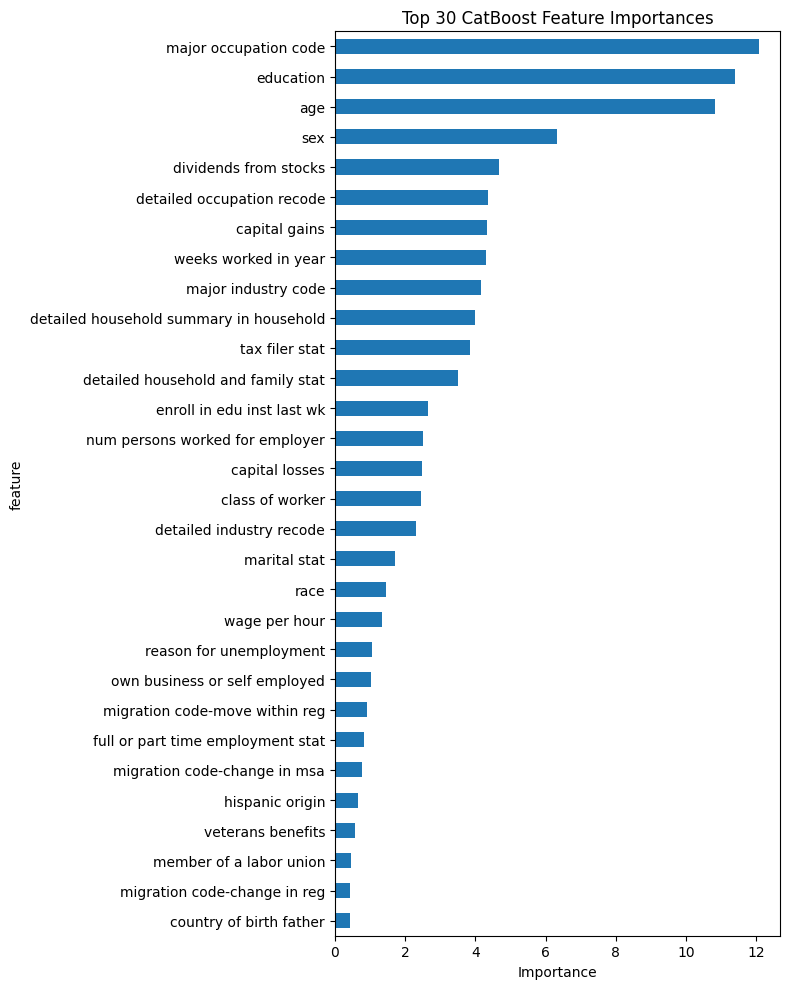

In [ ]:
feat_imp = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': cb_clf.get_feature_importance()
}).sort_values('importance', ascending=False).reset_index(drop=True)

# print(feat_imp.head(30))

fig, ax = plt.subplots(figsize=(8, 10))
feat_imp.head(30).sort_values('importance').plot.barh(x='feature', y='importance', ax=ax, legend=False)
ax.set_xlabel('Importance')
ax.set_title('Top 30 CatBoost Feature Importances')
plt.tight_layout()
plt.show()


In [ ]:
# Cutoff when cumulative feature importance hits 0.95
feat_imp['cumulative'] = feat_imp['importance'].cumsum() / feat_imp['importance'].sum()
cutoff = feat_imp[feat_imp['cumulative'] <= 0.95].shape[0]
print(f"Features needed for 95% cumulative importance: {cutoff}")

top_features = feat_imp.head(cutoff)['feature'].tolist()
print(f"Keeping {len(top_features)} features")

X_train_fs = X_train[top_features]
X_test_fs  = X_test[top_features]
cat_col_indices_fs = [X_train_fs.columns.get_loc(c) for c in categorical_columns if c in top_features]

Features needed for 95% cumulative importance: 24
Keeping 24 features


In [ ]:
print(top_features)
top_features = ["major occupation code","education","age","sex","dividends from stocks","detailed occupation recode","capital gains","weeks worked in year","major industry code","detailed household summary in household","tax filer stat","detailed household and family stat","enroll in edu inst last wk","num persons worked for employer","capital losses","class of worker","detailed industry recode","marital stat","race","wage per hour","reason for unemployment","own business or self employed","migration code-move within reg","full or part time employment stat"]

['major occupation code', 'education', 'age', 'sex', 'dividends from stocks', 'detailed occupation recode', 'capital gains', 'weeks worked in year', 'major industry code', 'detailed household summary in household', 'tax filer stat', 'detailed household and family stat', 'enroll in edu inst last wk', 'num persons worked for employer', 'capital losses', 'class of worker', 'detailed industry recode', 'marital stat', 'race', 'wage per hour', 'reason for unemployment', 'own business or self employed', 'migration code-move within reg', 'full or part time employment stat']


In [ ]:
from catboost import CatBoostClassifier, Pool

train_pool_fs = Pool(X_train_fs, y_train, cat_features=cat_col_indices_fs, weight=w_train)
val_pool_fs   = Pool(X_test_fs,  y_test,  cat_features=cat_col_indices_fs, weight=w_test)

cb_clf_fs = CatBoostClassifier(
    random_state=131,
    eval_metric='PRAUC',
    iterations=3000,        # set high, early stopping will cut it
    early_stopping_rounds=100,  # stop if no improvement for 100 rounds
    verbose=100
)

cb_clf_fs.fit(train_pool_fs, eval_set=val_pool_fs)

Learning rate set to 0.064412
0:	learn: 0.1171936	test: 0.5203921	best: 0.5203921 (0)	total: 666ms	remaining: 33m 16s
100:	learn: 0.5768920	test: 0.5731669	best: 0.5731669 (100)	total: 52.5s	remaining: 25m 6s
200:	learn: 0.6091673	test: 0.6054656	best: 0.6054656 (200)	total: 1m 40s	remaining: 23m 20s
300:	learn: 0.6777696	test: 0.6712588	best: 0.6712588 (300)	total: 2m 46s	remaining: 24m 56s
400:	learn: 0.6998888	test: 0.6844732	best: 0.6844732 (400)	total: 3m 58s	remaining: 25m 45s
500:	learn: 0.7131480	test: 0.6911532	best: 0.6912041 (499)	total: 5m 6s	remaining: 25m 31s
600:	learn: 0.7229429	test: 0.6942848	best: 0.6942848 (600)	total: 6m 14s	remaining: 24m 54s
700:	learn: 0.7311517	test: 0.6967525	best: 0.6967839 (696)	total: 7m 25s	remaining: 24m 19s
800:	learn: 0.7389069	test: 0.6993807	best: 0.6993849 (799)	total: 8m 32s	remaining: 23m 27s
900:	learn: 0.7453111	test: 0.7004929	best: 0.7005108 (897)	total: 9m 41s	remaining: 22m 35s
1000:	learn: 0.7514667	test: 0.7010810	best: 0.7

CatBoostClassifier(early_stopping_rounds=100, eval_metric='PRAUC', iterations=3000, random_state=131, verbose=100)

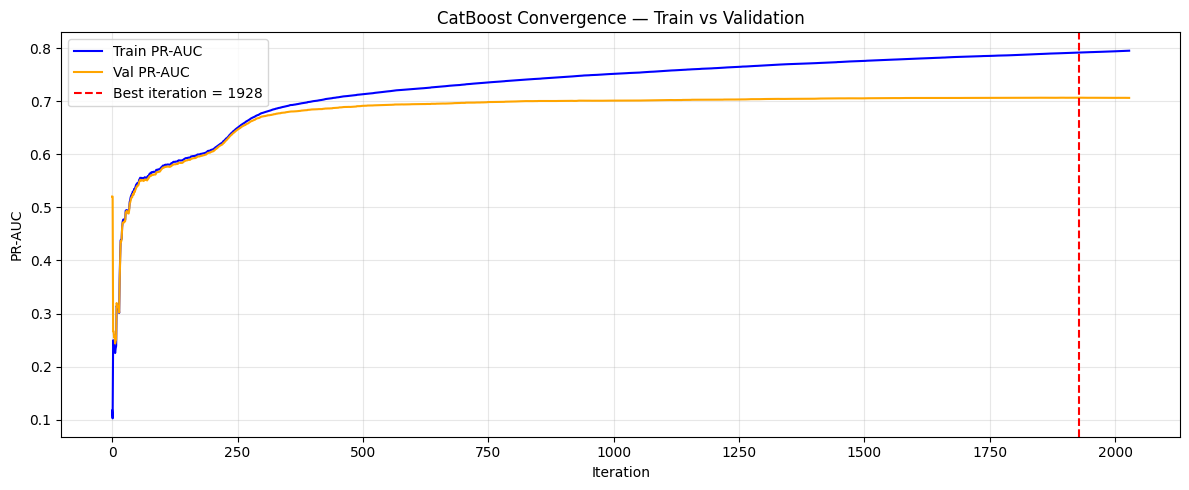

In [ ]:
train_prauc = cb_clf_fs.evals_result_['learn']['PRAUC']
val_prauc = cb_clf_fs.evals_result_['validation']['PRAUC']

plt.figure(figsize=(12, 5))
plt.plot(train_prauc, label='Train PR-AUC', color='blue')
plt.plot(val_prauc, label='Val PR-AUC', color='orange')
plt.axvline(cb_clf_fs.best_iteration_, color='red', linestyle='--',
            label=f'Best iteration = {cb_clf_fs.best_iteration_}')
plt.xlabel('Iteration')
plt.ylabel('PR-AUC')
plt.title('CatBoost Convergence — Train vs Validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import average_precision_score

y_proba = cb_clf_fs.predict_proba(X_test_fs)[:, 1]
y_pred = cb_clf_fs.predict(X_test_fs)

pr_auc = average_precision_score(y_test, y_proba, sample_weight = w_test)
f1 = f1_score(y_test, y_pred, sample_weight = w_test)
roc = roc_auc_score(y_test, y_proba, sample_weight = w_test)

print("Weighted results")
print(f"PR-AUC: {pr_auc:.4f}  |  F1: {f1:.4f}  |  ROC-AUC: {roc:.4f}")

print("\nWeighted Classification Report \n")
print(classification_report(y_test, y_pred, sample_weight = w_test))

cf_matrix =  confusion_matrix(y_test, y_pred,  sample_weight = w_test)
print(" \n Weighted Confusion Matrix:\n\n", confusion_matrix(y_test, y_pred, sample_weight = w_test))


Weighted results
PR-AUC: 0.7066  |  F1: 0.6014  |  ROC-AUC: 0.9568

Weighted Classification Report 

              precision    recall  f1-score   support

           0       0.97      0.99      0.98 64078555.48999995
           1       0.77      0.49      0.60 4482235.690000001

    accuracy                           0.96 68560791.17999995
   macro avg       0.87      0.74      0.79 68560791.17999995
weighted avg       0.95      0.96      0.95 68560791.17999995

 
 Weighted Confusion Matrix:

 [[63421606.90999997   656948.58      ]
 [ 2272188.31        2210047.38      ]]


Current PR_AUC 0.7066

In [ ]:
# dataset is large enough, CV might not buy much, can test later for bias by measuring std dev

### HyperParameter Tuning - HYperopt (bayesian search)

In [ ]:
# only did 30 evals due to time and gpu constraints

In [ ]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import average_precision_score
import numpy as np

train_pool_fs = Pool(X_train_fs, y_train, cat_features=cat_col_indices_fs, weight=w_train)
val_pool_fs   = Pool(X_test_fs,  y_test,  cat_features=cat_col_indices_fs, weight=w_test)

# search space
space = {
    'depth':               hp.choice('depth', [5, 6, 7]),
    'learning_rate':       hp.loguniform('learning_rate', np.log(0.01), np.log(0.1)),
    'l2_leaf_reg':         hp.loguniform('l2_leaf_reg', np.log(1), np.log(20)),
    'bagging_temperature': hp.uniform('bagging_temperature', 0.0, 2.0),
    'random_strength':     hp.uniform('random_strength', 0.5, 3.0)
}


def objective(params):
    model = CatBoostClassifier(
        random_state=131,
        eval_metric='PRAUC',
        iterations=3000,
        early_stopping_rounds=100,
        verbose=0,
        **params
    )

    model.fit(train_pool_fs, eval_set=val_pool_fs)

    y_proba  = model.predict_proba(X_test_fs)[:, 1]
    pr_auc   = average_precision_score(y_test, y_proba, sample_weight=w_test)

    return {'loss': -pr_auc, 'status': STATUS_OK, 'best_iter': model.best_iteration_}

trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials,
    rstate=np.random.default_rng(131)
)
print(f"Best params : {best}")
print(f"Best PR-AUC : {-min(trials.losses()):.4f}")



100%|██████████| 30/30 [7:17:28<0:00:00, 1389.76s/trial, best loss: -0.7089182915182121]
Best params : {'depth': 6, 'learning_rate': np.float64(0.060605146816668724), 'bagging_temperature': np.float64(0.5733272884392024), 'l2_leaf_reg': np.float64(4.234523019280719), 'random_strength': np.float64(0.7921427827368106)}
Best PR-AUC : 0.7074


In [ ]:
# Retraining with best params
from hyperopt import space_eval

best_params = {'depth': 6, 'learning_rate': np.float64(0.060605146816668724), 'bagging_temperature': np.float64(0.5733272884392024), 'l2_leaf_reg': np.float64(4.234523019280719), 'random_strength': np.float64(0.7921427827368106)}


best_model = CatBoostClassifier(
    random_state=131,
    eval_metric='PRAUC',
    iterations=3000,
    early_stopping_rounds=100,
    verbose=100,
    **best_params
)

best_model.fit(train_pool_fs, eval_set=val_pool_fs)

y_proba = best_model.predict_proba(X_test_fs)[:, 1]
final_pr_auc = average_precision_score(y_test, y_proba, sample_weight=w_test)
print(f"Final weighted PR-AUC : {final_pr_auc:.4f}")

0:	learn: 0.1172311	test: 0.5203921	best: 0.5203921 (0)	total: 779ms	remaining: 38m 56s
100:	learn: 0.5827622	test: 0.5814149	best: 0.5814149 (99)	total: 38.4s	remaining: 18m 21s
200:	learn: 0.6128679	test: 0.6103226	best: 0.6103226 (200)	total: 1m 47s	remaining: 24m 55s
300:	learn: 0.6728228	test: 0.6675187	best: 0.6675187 (300)	total: 3m 3s	remaining: 27m 24s
400:	learn: 0.6959661	test: 0.6828451	best: 0.6828451 (400)	total: 4m 29s	remaining: 29m 7s
500:	learn: 0.7092881	test: 0.6897590	best: 0.6897590 (500)	total: 5m 29s	remaining: 27m 24s
600:	learn: 0.7191627	test: 0.6933827	best: 0.6933827 (600)	total: 6m 23s	remaining: 25m 29s
700:	learn: 0.7262598	test: 0.6956206	best: 0.6956697 (693)	total: 7m 17s	remaining: 23m 55s
800:	learn: 0.7331704	test: 0.6973897	best: 0.6974600 (790)	total: 8m 10s	remaining: 22m 26s
900:	learn: 0.7391840	test: 0.6994412	best: 0.6994415 (898)	total: 9m 5s	remaining: 21m 11s
1000:	learn: 0.7448665	test: 0.7015637	best: 0.7015637 (1000)	total: 10m 3s	rema

In [ ]:
from sklearn.metrics import *

y_proba = best_model.predict_proba(X_test_fs)[:, 1]
y_pred = best_model.predict(X_test_fs)

pr_auc = average_precision_score(y_test, y_proba, sample_weight = w_test)
f1 = f1_score(y_test, y_pred, sample_weight = w_test)
roc = roc_auc_score(y_test, y_proba, sample_weight = w_test)

print("Weighted results")
print(f"PR-AUC: {pr_auc:.4f}  |  F1: {f1:.4f}  |  ROC-AUC: {roc:.4f}")

print("\nWeighted Classification Report \n")
print(classification_report(y_test, y_pred, sample_weight = w_test))

cf_matrix =  confusion_matrix(y_test, y_pred,  sample_weight = w_test)
print(" \n Weighted Confusion Matrix:\n\n", confusion_matrix(y_test, y_pred, sample_weight = w_test))


Weighted results
PR-AUC: 0.7074  |  F1: 0.6008  |  ROC-AUC: 0.9569

Weighted Classification Report 

              precision    recall  f1-score   support

           0       0.97      0.99      0.98 64078555.48999995
           1       0.77      0.49      0.60 4482235.690000001

    accuracy                           0.96 68560791.17999995
   macro avg       0.87      0.74      0.79 68560791.17999995
weighted avg       0.95      0.96      0.95 68560791.17999995

 
 Weighted Confusion Matrix:

 [[63419764.05999995   658791.43      ]
 [ 2274550.91        2207684.78      ]]


Current best PRAUC = 0.7074

### Cross validation check

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import numpy as np

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=131)
fold_scores = []

for tr_idx, val_idx in cv.split(X_train_fs, y_train):
    X_tr  = X_train_fs.iloc[tr_idx]
    X_val = X_train_fs.iloc[val_idx]
    y_tr  = y_train.iloc[tr_idx]
    y_val = y_train.iloc[val_idx]
    w_tr  = w_train.iloc[tr_idx]
    w_val = w_train.iloc[val_idx]

    tr_pool  = Pool(X_tr,  y_tr,  cat_features=cat_col_indices_fs, weight=w_tr)
    val_pool = Pool(X_val, y_val, cat_features=cat_col_indices_fs, weight=w_val)

    cv_model = CatBoostClassifier(
        random_state=131,
        eval_metric='PRAUC',
        iterations=3000,
        early_stopping_rounds=100,
        verbose=0,
        **best_params

    )

    cv_model.fit(tr_pool, eval_set=val_pool)
    y_proba = cv_model.predict_proba(X_val)[:, 1]
    fold_scores.append(average_precision_score(y_val, y_proba, sample_weight=w_val))

print(f"CV Mean PR-AUC: {np.mean(fold_scores):.4f} \n CV Stddev PR-AUC: {np.std(fold_scores):.4f}")

CV Mean PR-AUC: 0.6862 
 CV Stddev PR-AUC: 0.0028


**Final PR-AUC  = 0.6862** <br>
Low stddev indicate model is not overfitting to our test set could because data is large so teh test split is not a niche but well generalized

### EVALUATION of best model

In [ ]:
y_proba = best_model.predict_proba(X_test_fs)[:, 1]
y_pred = best_model.predict(X_test_fs)

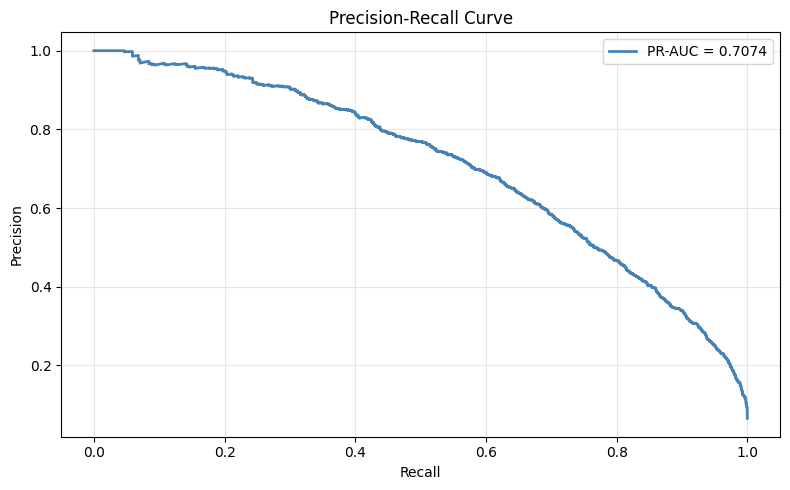

In [ ]:
# PR Curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba, sample_weight=w_test)
pr_auc = average_precision_score(y_test, y_proba, sample_weight=w_test)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='steelblue', linewidth=2, label=f'PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

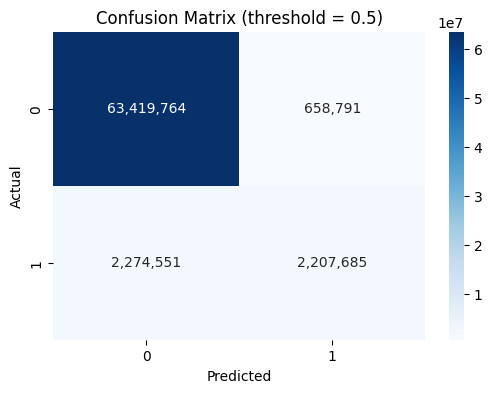



 Weighted PR-AUC : 0.7074


F1 score with threshold (0.5)  0.6008358498854747


 Weighted Classification report with threshold (0.5)
              precision    recall  f1-score   support

           0       0.97      0.99      0.98 64078555.48999995
           1       0.77      0.49      0.60 4482235.690000001

    accuracy                           0.96 68560791.17999995
   macro avg       0.87      0.74      0.79 68560791.17999995
weighted avg       0.95      0.96      0.95 68560791.17999995



In [ ]:
# Confusion Matrix at default threshold 0.5
cf_matrix = confusion_matrix(y_test, y_pred, sample_weight=w_test)

plt.figure(figsize=(6, 4))
sns.heatmap(cf_matrix, annot=True, fmt=',.0f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (threshold = 0.5)')
plt.show()

print(f"\n\n Weighted PR-AUC : {pr_auc:.4f}")

print("\n\nF1 score with threshold (0.5) ", f1_score(y_test, y_pred, sample_weight=w_test))
print("\n\n Weighted Classification report with threshold (0.5)")
print(classification_report(y_test, y_pred, sample_weight=w_test))

* PR-AUC: 0.7074 <br>
* F1 score: 0.6 <br>

Need to tune threshold because of imbalanced dataset

Best threshold : 0.3377
Precision : 0.6760
Recall : 0.6212
F1 : 0.6474


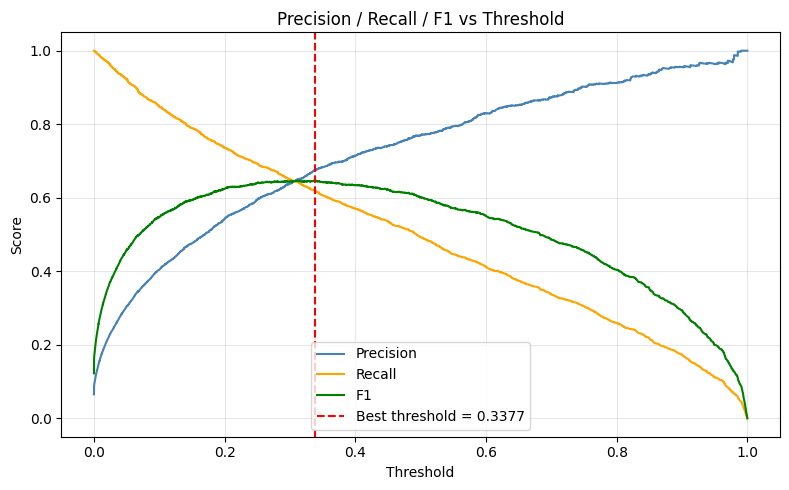

In [ ]:
# Threshold tuning
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx   = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold : {best_threshold:.4f}")
print(f"Precision : {precisions[best_idx]:.4f}")
print(f"Recall : {recalls[best_idx]:.4f}")
print(f"F1 : {f1_scores[best_idx]:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recalls[:-1],    label='Recall',    color='orange')
plt.plot(thresholds, f1_scores,       label='F1',        color='green')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.4f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Best Threshold = 0.3377

* F1 score @ 0.3377: 0.6474 <br>
* Precision score @ 0.3377: 0.6760 <br>
* Recall score @ 0.3377: 0.6212 <br>

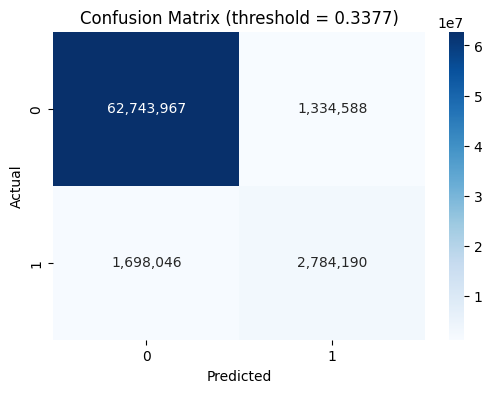



F1 score with threshold (0.3377)  0.6474096695799786


 Weighted Classification report with threshold (0.3377)
              precision    recall  f1-score   support

           0       0.97      0.98      0.98 64078555.48999995
           1       0.68      0.62      0.65 4482235.690000001

    accuracy                           0.96 68560791.17999995
   macro avg       0.82      0.80      0.81 68560791.17999995
weighted avg       0.95      0.96      0.95 68560791.17999995



In [ ]:
# Confusion Matrix at best threshold
y_pred_tuned = (y_proba >= best_threshold).astype(int)
cf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned, sample_weight=w_test)

plt.figure(figsize=(6, 4))
sns.heatmap(cf_matrix_tuned, annot=True, fmt=',.0f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (threshold = {best_threshold:.4f})')
plt.show()

print("\n\nF1 score with threshold (0.3377) ", f1_score(y_test, y_pred_tuned, sample_weight=w_test))
print("\n\n Weighted Classification report with threshold (0.3377)")
print(classification_report(y_test, y_pred_tuned, sample_weight=w_test))

In [ ]:
# Save the model

import os
os.makedirs('model', exist_ok=True)
best_model.save_model('../model/catboost_model')
print("Model saved to model/catboost_model")

Model saved to model/catboost_model


# Fairness

In [ ]:
for col in ['sex', 'race']:
    print(f"\n--- {col} ---")
    for group in X_train_fs[col].unique():
        mask     = X_train_fs[col] == group
        pos_rate = y_train[mask].mean()
        n        = mask.sum()
        print(f"{group}: positive rate = {pos_rate:.3f}, n = {n}")


--- sex ---
Female: positive rate = 0.034, n = 62932
Male: positive rate = 0.131, n = 59384

--- race ---
White: positive rate = 0.088, n = 101560
Black: positive rate = 0.037, n = 12064
Asian or Pacific Islander: positive rate = 0.080, n = 4421
Other: positive rate = 0.028, n = 2764
Amer Indian Aleut or Eskimo: positive rate = 0.027, n = 1507


In [ ]:
from sklearn.metrics import average_precision_score
import pandas as pd

y_proba      = best_model.predict_proba(X_test_fs)[:, 1]
y_pred_tuned = (y_proba >= best_threshold).astype(int)

def fairness_report(col):
    rows = []
    for group in X_test_fs[col].unique():
        mask = X_test_fs[col] == group
        y_t  = y_test[mask].values
        y_d  = y_pred_tuned[mask]
        y_p  = y_proba[mask]
        w    = w_test[mask]

        tp = ((y_t == 1) & (y_d == 1)).sum()
        fp = ((y_t == 0) & (y_d == 1)).sum()
        tn = ((y_t == 0) & (y_d == 0)).sum()
        fn = ((y_t == 1) & (y_d == 0)).sum()

        rows.append({
            'group':    group,
            'n':        mask.sum(),
            'pr_auc':   round(average_precision_score(y_t, y_p, sample_weight=w), 4),
            'FNR':      round(fn / (fn + tp + 1e-9), 4),  # missed actual >50k
            'FPR':      round(fp / (fp + tn + 1e-9), 4),  # wrongly predicted >50k
        })

    df = pd.DataFrame(rows)
    print(f"\n=== Fairness Report: {col} ===\n")
    print(df.to_string(index=False))

fairness_report('sex')
fairness_report('race')


=== Fairness Report: sex ===

 group     n  pr_auc    FNR    FPR
  Male 14806  0.7532 0.3251 0.0505
Female 15774  0.5148 0.5948 0.0091

=== Fairness Report: race ===

                      group     n  pr_auc    FNR    FPR
                      White 25448  0.7177 0.3729 0.0315
  Asian or Pacific Islander  1081  0.6942 0.4286 0.0229
                      Black  3010  0.5032 0.5652 0.0106
Amer Indian Aleut or Eskimo   366  0.5145 0.7778 0.0084
                      Other   675  0.7359 0.4615 0.0030


* Only 3.4% of women earn >50k vs 13.1% of men in training data - the model had very few high-earning women to learn from, leading to a 59% FNR for women.
* Black (3.7%) and Native American (2.7%) groups have low positive rates than White (8.8%), and are much smaller in size - explaining their high FNRs of 56% and 78%.
* The model learned the disparities in the data reflecting  real historical income inequality, not a modeling error.

Need to be addressed when deploying or working with recent data

# Explainable AI (SHAP)

In [ ]:
import shap
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_fs)
shap_values.shape

(30580, 24)

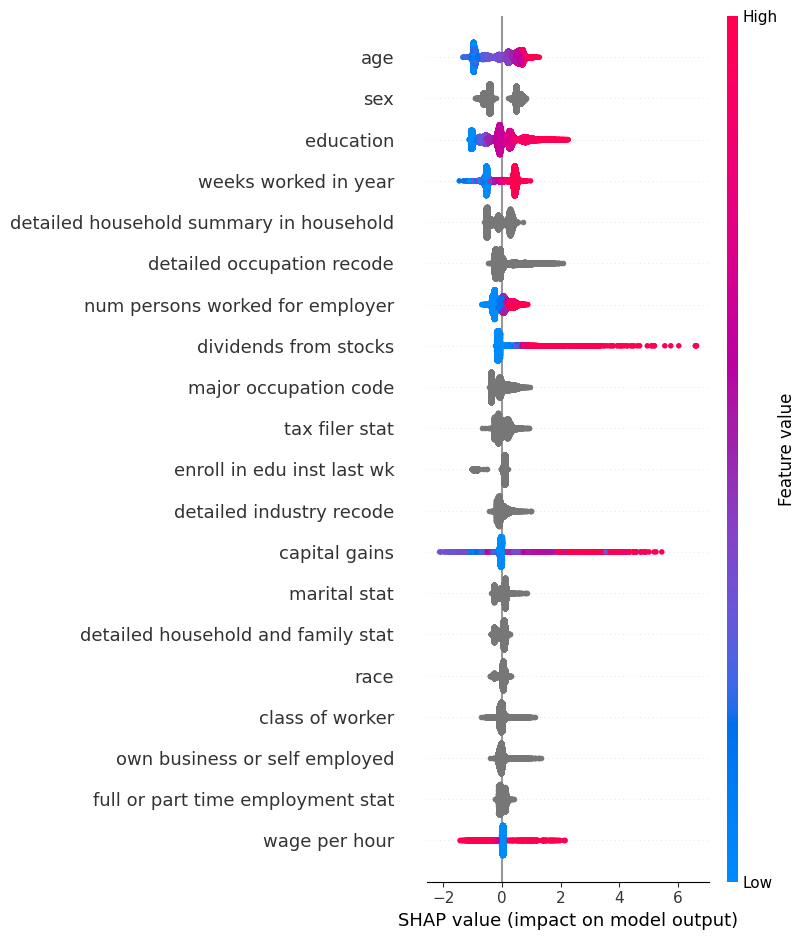

In [ ]:
shap.summary_plot(shap_values, X_test_fs)

Summary

* Higher Age values push the prediction towards the positive side
* Higher Education values push the prediction towards the positive side
* Higher number of weeks/capital gains/ dividends worked in a year push the prediction towards the positive side

**User level shap values can be used for better explainability/reasons leading to the prediction by the model**

In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0, :], X_test_fs.iloc[0, :])

For this user, <br>
* Age = 17, enrolled in High School, education = 8 (11th grade), children under 18 are some of the leading factors contributing towards income <\$50K
* Sex = Male, weeks worked = 50 is trying to push the prediction towards income >$50K

Overall Shap value is below baseline, and hence the prediction is that the individual is earning <$50K

In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[100, :], X_test_fs.iloc[100, :])

For this user, <br>
* Race = Black, dividends = 0 are pushing down the predictions towards income <\$50K
* Sex = Male, weeks worked = 52, age = 45, num persons worked for employer = 6 are pushing the prediction towards income >$50K

Overall Shap value is above baseline, and hence the prediction is that the individual is earning >$50K